# Trees cleaning


## 1  Setup

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np


# define which columns we want to keep
TREE_KEEP_COLS = [
    "CoM ID",
    "Common Name",
    "Scientific Name",
    "Genus",
    "Family",
    "Diameter Breast Height",
    "Year Planted",
    "Date Planted",
    "Age Description",
    "Useful Life Expectency",
    "Useful Life Expectency Value",
    "Precinct",
    "Located in",
    "Latitude",
    "Longitude",
]

# define rename mapping
TREE_RENAME_MAP = {
    "CoM ID": "com_id",
    "Common Name": "common_name",
    "Scientific Name": "scientific_name",
    "Genus": "genus",
    "Family": "family",
    "Diameter Breast Height": "diameter_breast_height",
    "Year Planted": "year_planted",
    "Date Planted": "date_planted",
    "Age Description": "age_description",
    "Useful Life Expectency": "useful_life_expectency",
    "Useful Life Expectency Value": "useful_life_expectency_value",
    "Precinct": "precinct",
    "Located in": "located_in",
    "Latitude": "latitude",
    "Longitude": "longitude",
}



## 2 — Load 


In [2]:
def load_tree_data(filepath: Path) -> pd.DataFrame:
    """
    Read raw tree CSV, keep only needed columns, and rename them to snake_case.
    """
    # Read raw file
    df = pd.read_csv(filepath, encoding="utf-8-sig")

    # Print raw shape and raw columns for checking
    print("Raw shape:", df.shape)
    print("\nRaw columns:")
    print(df.columns.tolist())

    # Keep only selected columns
    df = df[TREE_KEEP_COLS].copy()

    # Rename to snake_case
    df = df.rename(columns=TREE_RENAME_MAP)

    # Print result for checking
    print("\nAfter Step 1 shape:", df.shape)
    print("\nAfter Step 1 columns:")
    print(df.columns.tolist())

    return df

# load the data
tree_path = Path("trees-with-species-and-dimensions-urban-forest.csv")

tree_raw = load_tree_data(tree_path)

tree_raw.head()


Raw shape: (82064, 20)

Raw columns:
['CoM ID', 'Common Name', 'Scientific Name', 'Genus', 'Family', 'Diameter Breast Height', 'Year Planted', 'Date Planted', 'Age Description', 'Useful Life Expectency', 'Useful Life Expectency Value', 'Precinct', 'Located in', 'UploadDate', 'CoordinateLocation', 'Latitude', 'Longitude', 'Easting', 'Northing', 'geolocation']

After Step 1 shape: (82064, 15)

After Step 1 columns:
['com_id', 'common_name', 'scientific_name', 'genus', 'family', 'diameter_breast_height', 'year_planted', 'date_planted', 'age_description', 'useful_life_expectency', 'useful_life_expectency_value', 'precinct', 'located_in', 'latitude', 'longitude']


,com_id,common_name,scientific_name,genus,family,diameter_breast_height,year_planted,date_planted,age_description,useful_life_expectency,useful_life_expectency_value,precinct,located_in,latitude,longitude
0,1070378,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,20.0,2006,2006-12-15,Mature,> 41 years,50,South Yarra,Street,-37.832567,144.986879
1,1070382,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,21.0,2006,2006-12-15,Mature,> 41 years,50,South Yarra,Street,-37.831669,144.987059
2,1796650,Cook pine,Araucaria columnaris,Araucaria,Araucariaceae,NaN,2020,2020-12-14,Semi-mature,21 - 30 years,30,Carlton,Park,-37.802222,144.962852
3,1457913,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,25.0,2010,2010-12-14,Mature,> 41 years,50,Kensington,Park,-37.797537,144.923519
4,1457915,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,22.0,2010,2010-12-14,Mature,> 41 years,50,Kensington,Park,-37.797540,144.923459


## 3 clean


In [3]:
TEXT_COLS = [
    "common_name",
    "scientific_name",
    "genus",
    "family",
    "age_description",
    "useful_life_expectency",
    "precinct",
    "located_in",
]

# Melbourne range for validation
LAT_MIN, LAT_MAX = -38.1, -37.5
LON_MIN, LON_MAX = 144.7, 145.3

def clean_tree_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Basic cleaning for tree data:
    1. fill missing common_name with scientific_name
    2. drop rows missing core task fields
    3. trim text columns
    4. repair encoding artifacts
    5. convert dtypes
    6. validate coordinate range
    7. deduplicate by com_id
    """
    clean_df = df.copy()

    # fill missing common_name using scientific_name
    clean_df["common_name"] = clean_df["common_name"].fillna(clean_df["scientific_name"])

    # drop rows missing core task fields
    # For later tree task generation, we need at least name + coordinates
    clean_df = clean_df.dropna(subset=["common_name", "latitude", "longitude"])

    # trim text columns
    for col in TEXT_COLS:
        clean_df[col] = clean_df[col].astype("string").str.strip()

    # repair encoding artifacts
    # Example: HillŸ??s Weeping Fig -> Hill's Weeping Fig
    for col in TEXT_COLS:
        clean_df[col] = (
            clean_df[col]
            .str.replace("Ÿ??", "'", regex=False)
            .str.replace("??", "", regex=False)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

    # convert dtypes
    clean_df["com_id"] = pd.to_numeric(clean_df["com_id"], errors="coerce").astype("Int64")
    clean_df["diameter_breast_height"] = pd.to_numeric(
        clean_df["diameter_breast_height"], errors="coerce"
    )
    clean_df["year_planted"] = pd.to_numeric(
        clean_df["year_planted"], errors="coerce"
    ).astype("Int64")
    clean_df["useful_life_expectency_value"] = pd.to_numeric(
        clean_df["useful_life_expectency_value"], errors="coerce"
    )
    clean_df["latitude"] = pd.to_numeric(clean_df["latitude"], errors="coerce")
    clean_df["longitude"] = pd.to_numeric(clean_df["longitude"], errors="coerce")
    clean_df["date_planted"] = pd.to_datetime(clean_df["date_planted"], errors="coerce")

    # coordinate validation
    clean_df = clean_df[
        clean_df["latitude"].between(LAT_MIN, LAT_MAX)
        & clean_df["longitude"].between(LON_MIN, LON_MAX)
    ].copy()

    # remove rows with invalid com_id, then deduplicate
    clean_df = clean_df.dropna(subset=["com_id"])
    clean_df = clean_df.drop_duplicates(subset=["com_id"], keep="first").copy()

    # convert empty-like strings back to missing
    for col in TEXT_COLS:
        clean_df[col] = clean_df[col].replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA})

    return clean_df

tree_clean = clean_tree_data(tree_raw)

print("tree_raw shape :", tree_raw.shape)
print("tree_clean shape:", tree_clean.shape)

tree_clean.head()




tree_raw shape : (82064, 15)
tree_clean shape: (82064, 15)


,com_id,common_name,scientific_name,genus,family,diameter_breast_height,year_planted,date_planted,age_description,useful_life_expectency,useful_life_expectency_value,precinct,located_in,latitude,longitude
0,1070378,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,20.0,2006,2006-12-15,Mature,> 41 years,50,South Yarra,Street,-37.832567,144.986879
1,1070382,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,21.0,2006,2006-12-15,Mature,> 41 years,50,South Yarra,Street,-37.831669,144.987059
2,1796650,Cook pine,Araucaria columnaris,Araucaria,Araucariaceae,NaN,2020,2020-12-14,Semi-mature,21 - 30 years,30,Carlton,Park,-37.802222,144.962852
3,1457913,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,25.0,2010,2010-12-14,Mature,> 41 years,50,Kensington,Park,-37.797537,144.923519
4,1457915,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,22.0,2010,2010-12-14,Mature,> 41 years,50,Kensington,Park,-37.797540,144.923459


## 4  Generate location_group and location_label for the tree.




In [4]:
print("Missing precinct:", tree_clean["precinct"].isna().sum())
print("Missing located_in:", tree_clean["located_in"].isna().sum())

print("\nTop 20 precinct values:")
print(tree_clean["precinct"].value_counts(dropna=False).head(20))

print("\nTop 20 located_in values:")
print(tree_clean["located_in"].value_counts(dropna=False).head(20))

Missing precinct: 0
Missing located_in: 0

Top 20 precinct values:
precinct
Parkville                   28567
Melbourne                    9063
Kensington                   7555
West Melbourne               6756
Docklands                    5816
North Melbourne              4715
East Melbourne               4506
Carlton                      4368
South Yarra                  2631
Port Melbourne               2623
Southbank                    2338
Carlton North                2323
Flemington                    510
North And West Melbourne      113
Princes Hill                   65
Fishermans Bend                61
Central City                   26
Brunswick West                 24
Richmond                        2
Brunswick                       2
Name: count, dtype: Int64

Top 20 located_in values:
located_in
Park      48262
Street    33802
Name: count, dtype: Int64


In [5]:
def normalize_place_text(value):
    """
    Normalize a place-related text value for location grouping.
    """
    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    if value == "":
        return pd.NA

    # collapse repeated spaces
    value = " ".join(value.split())

    return value


def build_tree_location_fields(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build location_group and location_label for tree data.
    """
    tree_df_cleaned = df.copy()

    tree_df_cleaned["precinct_norm"] = tree_df_cleaned["precinct"].apply(normalize_place_text)
    tree_df_cleaned["located_in_norm"] = tree_df_cleaned["located_in"].apply(normalize_place_text)

    def combine_location(row):
        precinct = row["precinct_norm"]
        located_in = row["located_in_norm"]

        if pd.notna(precinct) and pd.notna(located_in):
            return f"{precinct} | {located_in}"
        elif pd.notna(precinct):
            return precinct
        elif pd.notna(located_in):
            return located_in
        else:
            return pd.NA

    tree_df_cleaned["location_group"] = tree_df_cleaned.apply(combine_location, axis=1)
    tree_df_cleaned["location_label"] = tree_df_cleaned["precinct_norm"].apply(
        lambda x: str(x).upper() if pd.notna(x) else pd.NA
    )


    return tree_df_cleaned




In [6]:
tree_loc = build_tree_location_fields(tree_clean)

print(tree_loc[["precinct", "located_in", "location_group", "location_label"]].head(10))

print("Missing location_group:", tree_loc["location_group"].isna().sum())
print("Unique location_group:", tree_loc["location_group"].nunique(dropna=True))

print("\nTop 30 location_group values:")
print(tree_loc["location_group"].value_counts(dropna=False).head(30))

      precinct located_in        location_group location_label
0  South Yarra     Street  South Yarra | Street    SOUTH YARRA
1  South Yarra     Street  South Yarra | Street    SOUTH YARRA
2      Carlton       Park        Carlton | Park        CARLTON
3   Kensington       Park     Kensington | Park     KENSINGTON
4   Kensington       Park     Kensington | Park     KENSINGTON
5   Kensington       Park     Kensington | Park     KENSINGTON
6   Kensington       Park     Kensington | Park     KENSINGTON
7   Kensington       Park     Kensington | Park     KENSINGTON
8   Kensington       Park     Kensington | Park     KENSINGTON
9   Kensington       Park     Kensington | Park     KENSINGTON
Missing location_group: 0
Unique location_group: 37

Top 30 location_group values:
location_group
Parkville | Park                     24853
Melbourne | Park                      4978
Melbourne | Street                    4085
North Melbourne | Street              4013
Kensington | Street                  

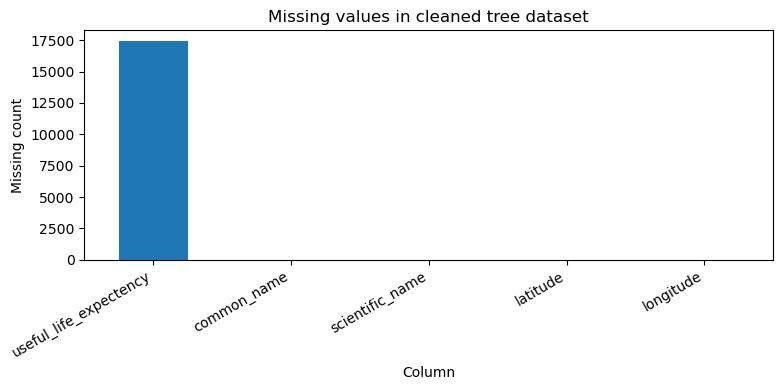

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

key_cols = [
    "common_name",
    "scientific_name",
    "useful_life_expectency",
    "latitude",
    "longitude"
]

missing_compare = pd.DataFrame({
    "raw_missing": tree_raw[key_cols].isna().sum(),
    "clean_missing": tree_clean[key_cols].isna().sum()
})

tree_clean[key_cols].isna().sum().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 4),
    title="Missing values in cleaned tree dataset"
)
plt.ylabel("Missing count")
plt.xlabel("Column")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

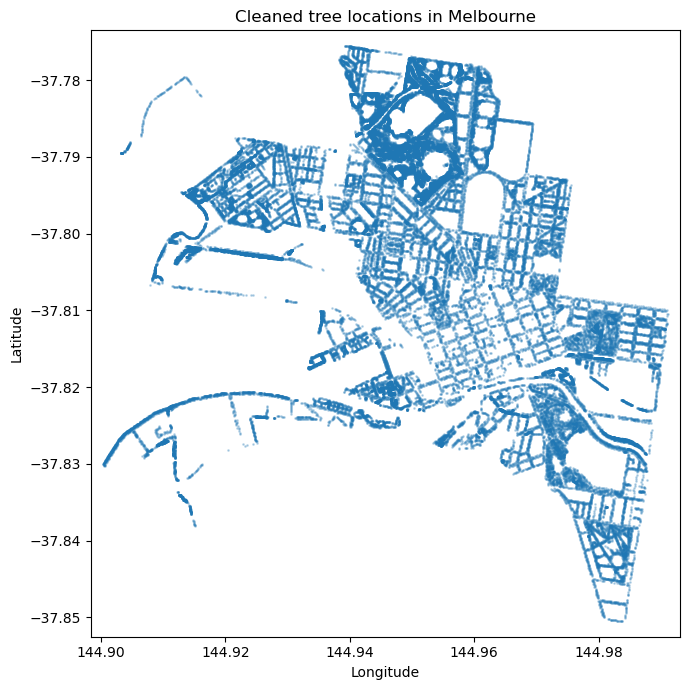

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(
    tree_clean["longitude"],
    tree_clean["latitude"],
    s=1,
    alpha=0.25
)
plt.xlim(tree_clean["longitude"].min() - 0.002, tree_clean["longitude"].max() + 0.002)
plt.ylim(tree_clean["latitude"].min() - 0.002, tree_clean["latitude"].max() + 0.002)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cleaned tree locations in Melbourne")
plt.tight_layout()
plt.show()

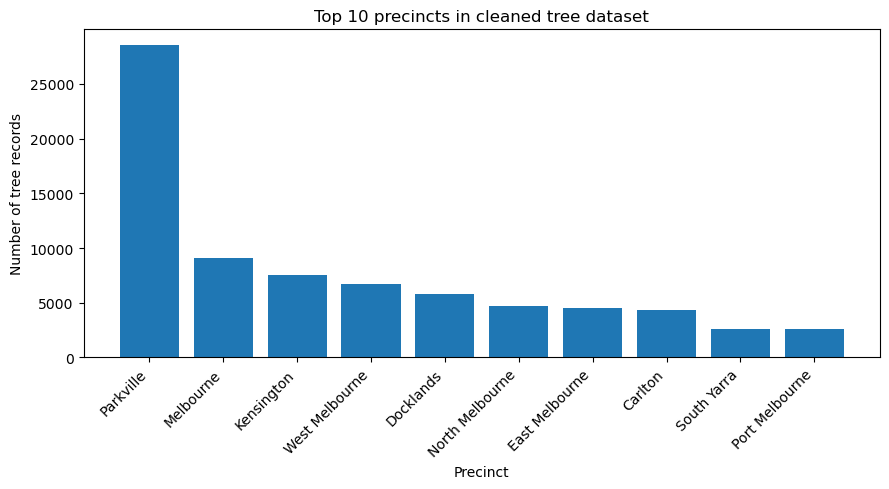

In [9]:
top_precinct = tree_clean["precinct"].value_counts().head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_precinct.index, top_precinct.values)
plt.title("Top 10 precincts in cleaned tree dataset")
plt.ylabel("Number of tree records")
plt.xlabel("Precinct")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

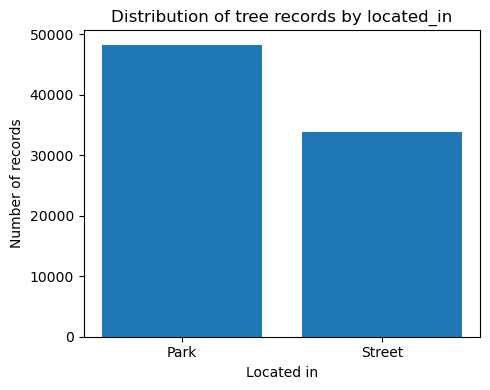

In [10]:
located_in_counts = tree_clean["located_in"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(located_in_counts.index, located_in_counts.values)
plt.title("Distribution of tree records by located_in")
plt.ylabel("Number of records")
plt.xlabel("Located in")
plt.tight_layout()
plt.show()

## 5 tree task build

In [11]:
def build_tree_task_content(
    df: pd.DataFrame,
    series_id: int = 1,
    geofence_radius_meter: int = 50,
    base_difficulty: int = 1,
    reward_point: int = 10,
) -> pd.DataFrame:
    """
    Build object-based task content for tree data.
    Use short description + short criteria style to align with backend sample.
    """
    output_df = df.copy()

    def clean_species_name(x):
        if pd.isna(x):
            return pd.NA
        return str(x).strip()

    # Clean common name for task text generation
    output_df["common_name_clean"] = output_df["common_name"].apply(clean_species_name)

    # build  task name
    output_df["task_name"] = output_df["common_name_clean"]

    # task_description: short user-facing instruction with location hint
    output_df["task_description"] = output_df.apply(
        lambda row: f"Take a picture of a {row['common_name_clean']} near {str(row['location_label']).lower()}.",
        axis=1
    )

    # evaluation_criteria short and judgeable for AI
    output_df["evaluation_criteria"] = output_df["common_name_clean"].apply(
        lambda x: f"A {x} tree should be present in the image."
    )

    # Default task fields
    output_df["series_id"] = series_id
    output_df["environment_type"] = "outdoor"
    output_df["task_type"] = "photo"
    output_df["geofence_radius_meter"] = geofence_radius_meter
    output_df["base_difficulty"] = base_difficulty
    output_df["reward_point"] = reward_point
    output_df["is_active"] = True

    return output_df





In [12]:
# tree tasks intialization
tree_task_base = build_tree_task_content(tree_loc)

tree_task_base.head(10)

,com_id,common_name,scientific_name,genus,family,diameter_breast_height,year_planted,date_planted,age_description,useful_life_expectency,...,task_name,task_description,evaluation_criteria,series_id,environment_type,task_type,geofence_radius_meter,base_difficulty,reward_point,is_active
0,1070378,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,20.0,2006,2006-12-15,Mature,> 41 years,...,Tulip Tree,Take a picture of a Tulip Tree near south yarra.,A Tulip Tree tree should be present in the image.,1,outdoor,photo,50,1,10,True
1,1070382,Tulip Tree,Liriodendron tulipifera,Liriodendron,Magnoliaceae,21.0,2006,2006-12-15,Mature,> 41 years,...,Tulip Tree,Take a picture of a Tulip Tree near south yarra.,A Tulip Tree tree should be present in the image.,1,outdoor,photo,50,1,10,True
2,1796650,Cook pine,Araucaria columnaris,Araucaria,Araucariaceae,NaN,2020,2020-12-14,Semi-mature,21 - 30 years,...,Cook pine,Take a picture of a Cook pine near carlton.,A Cook pine tree should be present in the image.,1,outdoor,photo,50,1,10,True
3,1457913,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,25.0,2010,2010-12-14,Mature,> 41 years,...,Yellow Box,Take a picture of a Yellow Box near kensington.,A Yellow Box tree should be present in the image.,1,outdoor,photo,50,1,10,True
4,1457915,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,22.0,2010,2010-12-14,Mature,> 41 years,...,Yellow Box,Take a picture of a Yellow Box near kensington.,A Yellow Box tree should be present in the image.,1,outdoor,photo,50,1,10,True
5,1457917,Flame Tree,Brachychiton acerifolius,Brachychiton,Malvaceae,11.0,2010,2010-12-14,Mature,> 41 years,...,Flame Tree,Take a picture of a Flame Tree near kensington.,A Flame Tree tree should be present in the image.,1,outdoor,photo,50,1,10,True
6,1457918,Brittle Gum,Eucalyptus mannifera,Eucalyptus,Myrtaceae,24.0,2010,2010-12-14,Mature,> 41 years,...,Brittle Gum,Take a picture of a Brittle Gum near kensington.,A Brittle Gum tree should be present in the im...,1,outdoor,photo,50,1,10,True
7,1457929,Yellow Box,Eucalyptus melliodora,Eucalyptus,Myrtaceae,80.0,2010,2010-12-14,Mature,> 41 years,...,Yellow Box,Take a picture of a Yellow Box near kensington.,A Yellow Box tree should be present in the image.,1,outdoor,photo,50,1,10,True
8,1457931,River red gum,Eucalyptus camaldulensis,Eucalyptus,Myrtaceae,20.0,2010,2010-12-14,Mature,> 41 years,...,River red gum,Take a picture of a River red gum near kensing...,A River red gum tree should be present in the ...,1,outdoor,photo,50,1,10,True
9,1457935,Black She Oak,Allocasuarina littoralis,Allocasuarina,Casuarinaceae,80.0,2010,2010-12-14,Mature,21 - 30 years,...,Black She Oak,Take a picture of a Black She Oak near kensing...,A Black She Oak tree should be present in the ...,1,outdoor,photo,50,1,10,True


In [13]:
invalid_task_names = {
    "unknown", "-", "--", "...", ".", "na", "n/a", "none", "null", ""
}

tree_task_base = tree_task_base[
    tree_task_base["task_name"].notna()
].copy()

tree_task_base["task_name"] = tree_task_base["task_name"].astype("string").str.strip()

tree_task_base = tree_task_base[
    ~tree_task_base["task_name"].str.lower().isin(invalid_task_names)
].copy()

tree_task_base = tree_task_base[
    ~tree_task_base["task_name"].str.fullmatch(r"[-.\s]+", na=False)
].copy()

print("After invalid task_name filtering:", len(tree_task_base))
print(tree_task_base["task_name"].value_counts(dropna=False).head(20))

After invalid task_name filtering: 81780
task_name
River red gum          8338
London Plane           5070
Drooping sheoak        3452
English Elm            3291
Yellow Box             3043
Black Wattle           3001
Spotted Gum            2902
River Sheoak           1665
Lightwood Wattle       1619
Sweet Bursaria         1574
Lemon Scented Gum      1402
Smooth-barked apple    1326
Yellow Gum             1235
Golden Wattle          1035
Chinaberry Tree         971
Brush Box               895
Coastal Banksia         786
Silver Wattle           771
Dutch Elm               740
Moreton Bay Fig         711
Name: count, dtype: Int64


In [14]:


def build_tree_selection_keys(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # same tree task / same species
    out["species_key"] = (
        out["scientific_name"]
        .fillna(out["common_name"])
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # precinct-level key only
    out["precinct_key"] = (
        out["location_label"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # same species in the same precinct
    out["species_precinct_key"] = out["species_key"] + " || " + out["precinct_key"]

    return out


def score_tree_tasks(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["quality_score"] = 0

    out["quality_score"] += out["common_name"].notna().astype(int) * 2
    out["quality_score"] += out["scientific_name"].notna().astype(int) * 2

    specific_name = ~out["scientific_name"].astype("string").str.contains(r"\bsp\.?\b", case=False, na=False)
    out["quality_score"] += specific_name.astype(int) * 2

    out["quality_score"] += out["location_label"].notna().astype(int) * 1

    park_or_garden = out["located_in"].astype("string").str.lower().isin(["park", "garden"])
    out["quality_score"] += park_or_garden.astype(int) * 2

    out["quality_score"] += out["diameter_breast_height"].notna().astype(int) * 1

    mature_like = out["age_description"].astype("string").str.lower().isin(["mature", "semi-mature"])
    out["quality_score"] += mature_like.astype(int) * 1

    # bigger DBH preferred
    dbh_rank = out["diameter_breast_height"].fillna(0)
    out["quality_score"] += (dbh_rank / 100).clip(upper=2)

    return out


def thin_tree_tasks(
    df: pd.DataFrame,
    max_per_species_precinct: int = 1,
    max_per_species_global: int = 8,
    max_per_precinct_global: int = 20,
) -> pd.DataFrame:
    out = df.copy()

    # keep higher-quality rows first
    out = out.sort_values(
        by=["quality_score", "diameter_breast_height"],
        ascending=[False, False],
        na_position="last"
    ).copy()

    # 1. same species in the same precinct -> keep only one
    out = out.groupby(
        "species_precinct_key",
        as_index=False,
        group_keys=False
    ).head(max_per_species_precinct)

    # 2. same species globally
    out = out.groupby(
        "species_key",
        as_index=False,
        group_keys=False
    ).head(max_per_species_global)

    # 3. same precinct globally
    out = out.groupby(
        "precinct_key",
        as_index=False,
        group_keys=False
    ).head(max_per_precinct_global)

    return out


In [15]:
tree_ranked = build_tree_selection_keys(tree_task_base)
tree_ranked = score_tree_tasks(tree_ranked)

tree_selected = thin_tree_tasks(
    tree_ranked,
    max_per_species_precinct=1,
    max_per_species_global=8,
    max_per_precinct_global=20,
)

## 6 Determination of final cols


In [16]:
FINAL_COLS = [
    "series_id",
    "task_name",
    "task_description",
    "evaluation_criteria",
    "environment_type",
    "task_type",
    "location_label",
    "latitude",
    "longitude",
    "st_point",
    "geofence_radius_meter",
    "base_difficulty",
    "reward_point",
    "is_active",
]

def build_st_point(longitude, latitude):
 
    if pd.isna(longitude) or pd.isna(latitude):
        return pd.NA
    return f"POINT({longitude} {latitude})"


def build_tree_task_seed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build final tree task seed aligned to the agreed export schema
    """
    output_col = df.copy()

    # build SQL-ready point text
    output_col["st_point"] = output_col.apply(
        lambda row: build_st_point(row["longitude"], row["latitude"]),
        axis=1
    )

    # keep only final export columns
    output_col = output_col[FINAL_COLS].copy()

    return output_col

tree_task_seed = build_tree_task_seed(tree_selected)

print(tree_task_seed.shape)
tree_task_seed.head(10)



(274, 14)


,series_id,task_name,task_description,evaluation_criteria,environment_type,task_type,location_label,latitude,longitude,st_point,geofence_radius_meter,base_difficulty,reward_point,is_active
32834,1,English Elm,Take a picture of a English Elm near south yarra.,A English Elm tree should be present in the im...,outdoor,photo,SOUTH YARRA,-37.838763,144.978829,POINT(144.9788292 -37.83876297),50,1,10,True
32308,1,Dutch Elm,Take a picture of a Dutch Elm near melbourne.,A Dutch Elm tree should be present in the image.,outdoor,photo,MELBOURNE,-37.822343,144.972785,POINT(144.9727852 -37.82234344),50,1,10,True
18637,1,Moreton Bay Fig,Take a picture of a Moreton Bay Fig near east ...,A Moreton Bay Fig tree should be present in th...,outdoor,photo,EAST MELBOURNE,-37.815332,144.980609,POINT(144.9806094 -37.81533175),50,1,10,True
19544,1,Huntingdon Elm,Take a picture of a Huntingdon Elm near melbou...,A Huntingdon Elm tree should be present in the...,outdoor,photo,MELBOURNE,-37.822281,144.972748,POINT(144.9727484 -37.82228101),50,1,10,True
74439,1,Moreton Bay Fig,Take a picture of a Moreton Bay Fig near carlton.,A Moreton Bay Fig tree should be present in th...,outdoor,photo,CARLTON,-37.805675,144.972993,POINT(144.9729931 -37.80567486),50,1,10,True
18667,1,Toromeo,Take a picture of a Toromeo near east melbourne.,A Toromeo tree should be present in the image.,outdoor,photo,EAST MELBOURNE,-37.815490,144.981434,POINT(144.9814343 -37.81549009),50,1,10,True
24468,1,Senegal Date Palm,Take a picture of a Senegal Date Palm near eas...,A Senegal Date Palm tree should be present in ...,outdoor,photo,EAST MELBOURNE,-37.811710,144.982362,POINT(144.9823619 -37.81171008),50,1,10,True
32808,1,Moreton Bay Fig,Take a picture of a Moreton Bay Fig near south...,A Moreton Bay Fig tree should be present in th...,outdoor,photo,SOUTH YARRA,-37.838525,144.981261,POINT(144.9812614 -37.83852547),50,1,10,True
73607,1,Toromeo,Take a picture of a Toromeo near melbourne.,A Toromeo tree should be present in the image.,outdoor,photo,MELBOURNE,-37.833779,144.983298,POINT(144.9832977 -37.83377924),50,1,10,True
33358,1,Moreton Bay Fig,Take a picture of a Moreton Bay Fig near west ...,A Moreton Bay Fig tree should be present in th...,outdoor,photo,WEST MELBOURNE,-37.810255,144.953910,POINT(144.9539096 -37.81025511),50,1,10,True


## 7 — Export `trees_cleaned.csv`


In [17]:
output_path = Path("task_seed_tree_nature.csv")

tree_task_seed.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Exported to: {output_path}")
print(f"Row count: {len(tree_task_seed)}")
print(f"Column count: {len(tree_task_seed.columns)}")

Exported to: task_seed_tree_nature.csv
Row count: 274
Column count: 14


In [18]:
import pandas as pd

input_file = "task_seed_tree_nature.csv"
output_file = "tree_task_2.csv"

df = pd.read_csv(input_file)

df["is_active"] = df["is_active"].map({
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0
})

df.to_csv(output_file, index=False, encoding="utf-8-sig")
